In [1]:
# ============================================================
# Student Performance Factors - Complete ML Project
# ============================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv") 
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
# 3. Basic Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [3]:
# 4. Missing Values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [4]:
# 5. Fill Missing Categorical Values with Mode
missing_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [5]:
# 6. Remove Invalid Score > 100
df = df[df["Exam_Score"] <= 100]

df["Exam_Score"].describe()

count    6606.000000
mean       67.230548
std         3.868502
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

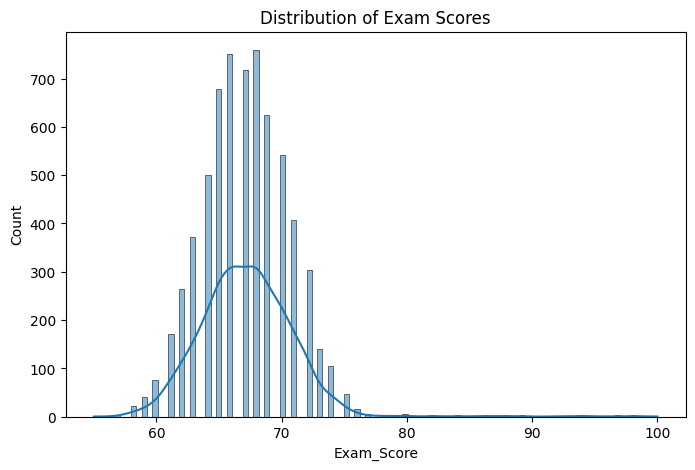

In [6]:
# 7. Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.show()

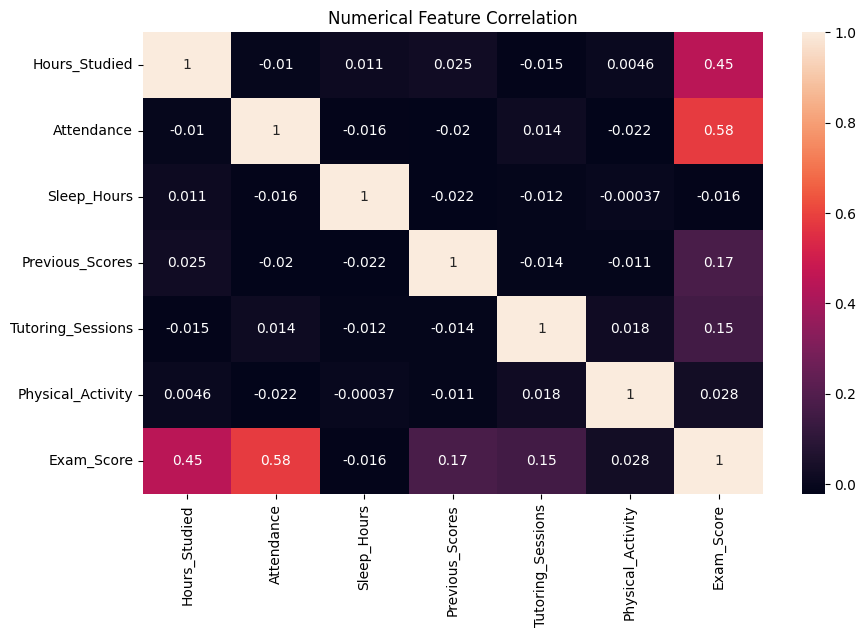

Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64


In [7]:
# 8. Numerical Correlation
num_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(num_cols.corr(), annot=True)
plt.title("Numerical Feature Correlation")
plt.show()

print(num_cols.corr()["Exam_Score"].sort_values(ascending=False))

In [8]:
# 9. Categorical Feature Analysis
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("\n" + "="*50)
    print(col)
    print(df.groupby(col)["Exam_Score"].mean().sort_values())


Parental_Involvement
Parental_Involvement
Low       66.332335
Medium    67.098156
High      68.092767
Name: Exam_Score, dtype: float64

Access_to_Resources
Access_to_Resources
Low       66.203351
Medium    67.124171
High      68.092152
Name: Exam_Score, dtype: float64

Extracurricular_Activities
Extracurricular_Activities
No     66.931435
Yes    67.433325
Name: Exam_Score, dtype: float64

Motivation_Level
Motivation_Level
Low       66.734504
Medium    67.330648
High      67.704321
Name: Exam_Score, dtype: float64

Internet_Access
Internet_Access
No     66.465863
Yes    67.292895
Name: Exam_Score, dtype: float64

Family_Income
Family_Income
Low       66.848428
Medium    67.334959
High      67.816246
Name: Exam_Score, dtype: float64

Teacher_Quality
Teacher_Quality
Low       66.753425
Medium    67.100175
High      67.659815
Name: Exam_Score, dtype: float64

School_Type
School_Type
Public     67.205569
Private    67.287705
Name: Exam_Score, dtype: float64

Peer_Influence
Peer_Influence
N

C:\Users\ROSE\AppData\Local\Temp\ipykernel_26456\807762594.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


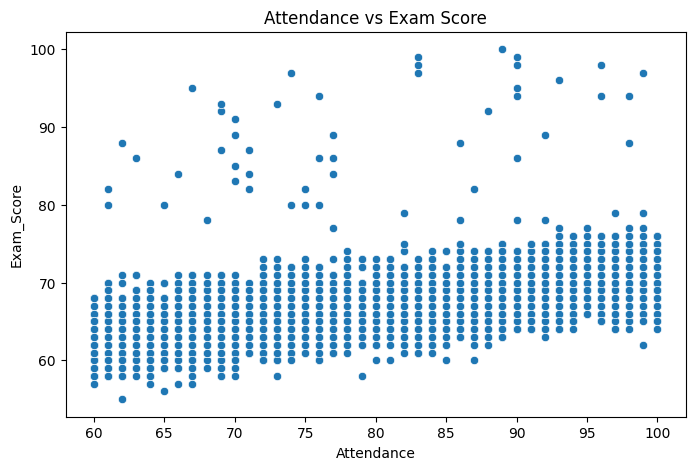

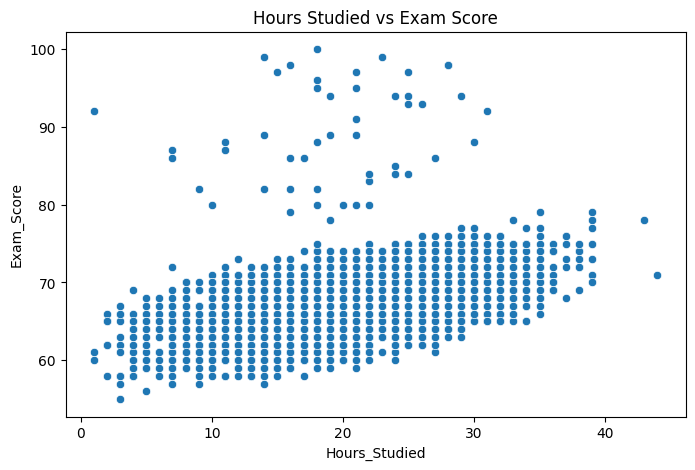

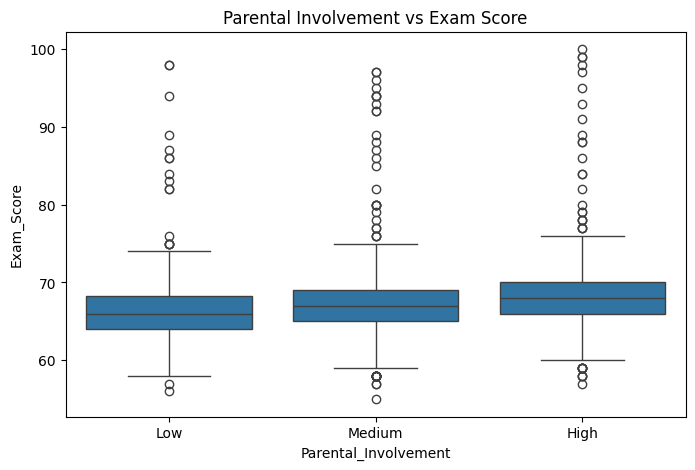

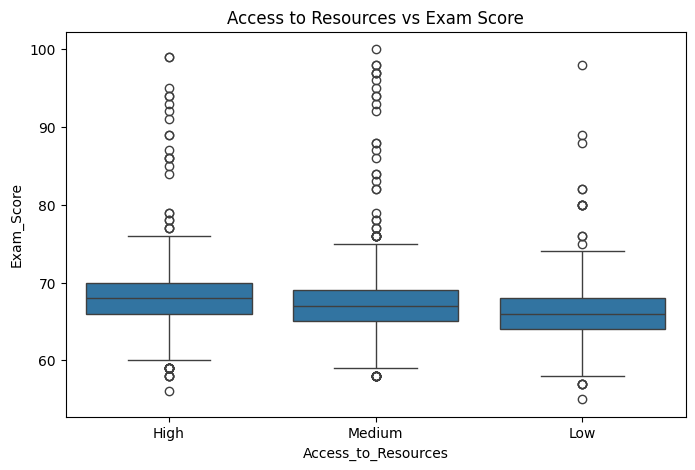

In [9]:
# 10. Important Visualizations

plt.figure(figsize=(8,5))
sns.scatterplot(x="Attendance", y="Exam_Score", data=df)
plt.title("Attendance vs Exam Score")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Hours Studied vs Exam Score")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=df)
plt.title("Parental Involvement vs Exam Score")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Access_to_Resources", y="Exam_Score", data=df)
plt.title("Access to Resources vs Exam Score")
plt.show()

In [10]:
# 11. Feature and Target Split
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

In [11]:
# 12. One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)
X_encoded.head()

(6606, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,True,False,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,True,False,False,True,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,False,True,False,True,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,True,False,False,True,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,False,True,False,True,...,False,True,True,False,False,False,False,False,True,False


In [12]:
# 13. Feature Correlation with Target
corr_target = X_encoded.corrwith(y)

print(
    corr_target.sort_values(
        ascending=False,
        key=abs
    ).head(20)
)

Attendance                               0.582458
Hours_Studied                            0.446514
Previous_Scores                          0.174461
Tutoring_Sessions                        0.153754
Access_to_Resources_Low                 -0.132259
Parental_Involvement_Low                -0.116914
Parental_Education_Level_Postgraduate    0.094961
Parental_Education_Level_High School    -0.088879
Learning_Disabilities_Yes               -0.085103
Distance_from_Home_Near                  0.083020
Motivation_Level_Low                    -0.082567
Family_Income_Low                       -0.081412
Peer_Influence_Positive                  0.080072
Extracurricular_Activities_Yes           0.063667
Internet_Access_Yes                      0.056447
Distance_from_Home_Moderate             -0.045282
Teacher_Quality_Medium                  -0.041796
Teacher_Quality_Low                     -0.040990
Parental_Involvement_Medium             -0.034843
Physical_Activity                        0.027943


In [13]:
# 14. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# 15. Feature Scaling for Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# 16. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE: 0.4159761177572447
RMSE: 1.5212625109260884
R2 Score: 0.8249999018449948


In [16]:
# 17. Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 1.136641452344932
RMSE: 2.01193479485779
R2 Score: 0.6939039188973785


<Axes: xlabel='Exam_Score'>

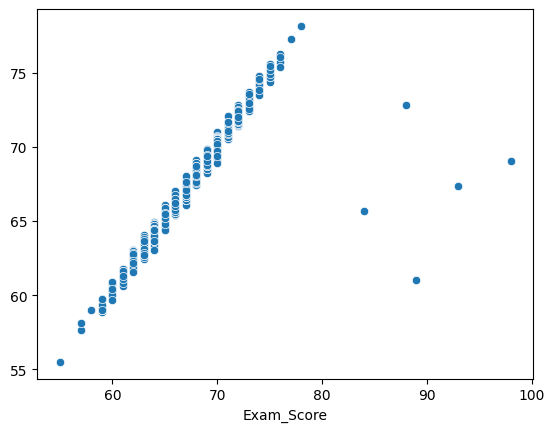

In [17]:
# 18. Compare Models
sns.scatterplot(
    x=y_test,
    y=lr_pred
)

In [18]:
# 19. Feature Importance - Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,Attendance,0.387954
0,Hours_Studied,0.239985
3,Previous_Scores,0.089454
4,Tutoring_Sessions,0.033529
5,Physical_Activity,0.029934
2,Sleep_Hours,0.026490
6,Parental_Involvement_Low,0.021319
8,Access_to_Resources_Low,0.020194
9,Access_to_Resources_Medium,0.011245
10,Extracurricular_Activities_Yes,0.010704


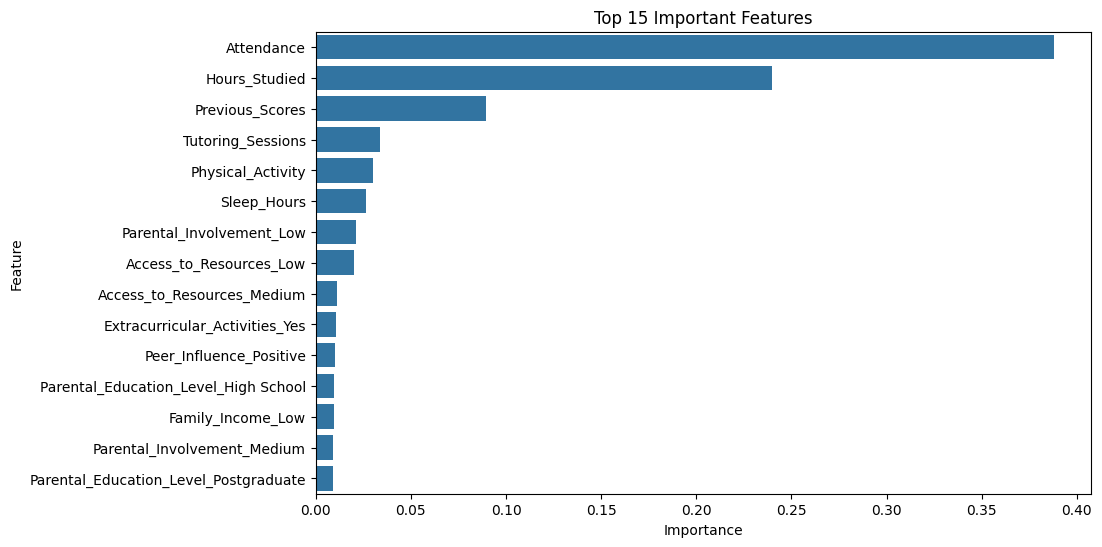

In [19]:
# 20. Plot Top 15 Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)
plt.title("Top 15 Important Features")
plt.show()

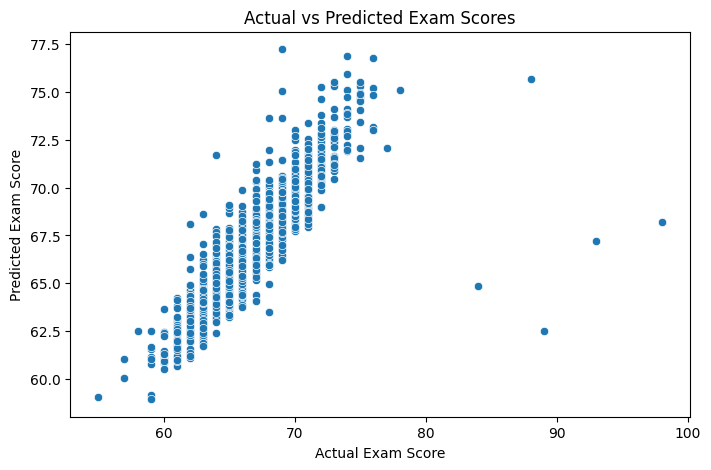

In [ ]:
# 21. Actual vs Predicted - Best Model
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=lr_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores - Linear Regression")
plt.show()

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(ridge_r2)

0.8249972214198467


In [23]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print(lasso_r2)

0.8242491397109492


In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

print(gbr_r2)

0.777891701232476


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        gbr_mae
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        gbr_rmse
    ],
    "R2": [
        lr_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        gbr_r2
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,R2
0,Linear Regression,0.825000
1,Ridge,0.824997
2,Lasso,0.824249
4,Gradient Boosting,0.777892
3,Random Forest,0.693904


Linear Regression achieved the highest R² score of 0.825,
explaining approximately 82.5% of the variation in student exam scores.

The strong performance of Linear Regression compared to
Random Forest and Gradient Boosting indicates that the
relationship between student factors and exam scores is
predominantly linear.

# Final Insights:
1. Attendance has the strongest positive relationship with Exam Score.
2. Hours Studied is also a strong predictor.
3. Previous Scores and Tutoring Sessions have moderate impact.
4. Sleep Hours and Physical Activity show weak linear relationship.
5. Parental Involvement and Access to Resources show clear positive trends.
6. Gender has almost no visible impact on Exam Score.

Linear Regression achieved the highest R² score (0.825),
outperforming Ridge, Lasso, Gradient Boosting, and Random Forest.
The results indicate that student performance is largely driven
by linear relationships, with Attendance and Hours Studied being
the strongest predictors of exam scores.